In [1]:
!pip install --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q xformers trl peft accelerate bitsandbytes
!pip install -q pandas networkx tqdm matplotlib pyvis


  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-n8mn32_q/unsloth_8329390c2b384e628323b827872d66da
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-n8mn32_q/unsloth_8329390c2b384e628323b827872d66da
  Resolved https://github.com/unslothai/unsloth.git to commit faea796c35e6ff1d1e522267bfd7ca62aa567bb3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 206.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 340.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 165.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.6/869.6 kB 802.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 155.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 837.6 MB/s eta 0:00:

In [2]:
import os, sys

REPO_DIR = '/content/Information-Retrieval'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Lifunn/Information-Retrieval.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull

%cd {REPO_DIR}/auto-hkg

if 'src' not in sys.path[0]:
    sys.path.insert(0, 'src')

os.makedirs('output/graph', exist_ok=True)
os.makedirs('output/logs', exist_ok=True)
os.makedirs('data', exist_ok=True)

print('Repository siap. Working directory:', os.getcwd())


Cloning into '/content/Information-Retrieval'...
remote: Enumerating objects: 107, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 107 (delta 42), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (107/107), 540.92 KiB | 2.06 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/Information-Retrieval/auto-hkg
✅ Repository siap. Working directory: /content/Information-Retrieval/auto-hkg


In [3]:
import os, shutil
from google.colab import files

target = 'data/Knowledge_Base_Sample.csv'

if os.path.exists(target):
    print(f'Dataset sudah ada di: {target}')
else:
    print('Upload file Knowledge_Base_Sample.csv...')
    uploaded = files.upload()
    for filename in uploaded.keys():
        shutil.move(filename, target)
    print(f'Dataset tersimpan di: {target}')

# Verifikasi
import pandas as pd
df = pd.read_csv(target, sep=';')
df.columns = [c.strip() for c in df.columns]
print(f'Total baris  : {len(df)}')
print(f'Kolom        : {list(df.columns)}')
print(df['Level Kognitif'].value_counts())


Dataset sudah ada di: data/Knowledge_Base_Sample.csv
Total baris  : 1200
Kolom        : ['Konteks', 'Pertanyaan', 'Level Kognitif']
Level Kognitif
C1-Mengingat       200
C2-Memahami        200
C3-Menerapkan      200
C4-Menganalisis    200
C5-Mengevaluasi    200
C6-Mencipta        200
Name: count, dtype: int64


In [5]:
import os, json

cp = 'output/logs/checkpoint.json'

# Cek checkpoint yang ada
if os.path.exists(cp):
    ck = json.load(open(cp))
    print(f'Checkpoint ditemukan: {ck["processed"]} baris sudah diproses.')
    print('Jalankan cell ini untuk reset, atau skip untuk lanjut dari checkpoint.')
else:
    print('Tidak ada checkpoint — pipeline akan mulai dari awal.')

# Uncomment untuk reset:
# os.remove(cp)
# print('✅ Checkpoint dihapus, pipeline akan mulai dari awal.')


Tidak ada checkpoint — pipeline akan mulai dari awal.


In [6]:
import importlib, sys

for mod in ['llm_client', 'auto_hkg', 'graph_builder', 'schema_validator']:
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])

from auto_hkg import AutoHKG, HKGConfig

cfg = HKGConfig(
    provider='unsloth',
    model='unsloth/gemma-4-E2B-it-unsloth-bnb-4bit',
    max_new_tokens=256,
    context_max_chars=500,
    data_path='data/Knowledge_Base_Sample.csv',
    batch_size=5,
    sleep_between_batches=0.0,
    retry_delay=0.0,
)

pipeline = AutoHKG(cfg)
pipeline.run()


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
[Unsloth] Model         : unsloth/gemma-4-E2B-it-unsloth-bnb-4bit
[Unsloth] dtype         : torch.bfloat16
[Unsloth] load_in_4bit  : True
[Unsloth] max_seq_length: 2048
[Unsloth] Loading model weights. First run may take 3-10 minutes...
==((====))==  Unsloth 2026.5.8: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json:   0%|          | 0.00/301k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/203 [00:00<?, ?B/s]

...

chat_template.jinja:   0%|          | 0.00/16.8k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/19.9k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

[Unsloth] Model loaded successfully.


Processing batches:   0%|          | 0/240 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:239: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/_ops.py:186: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_s

In [8]:
# import torch, time

# for i in range(40):
#     allocated = torch.cuda.memory_allocated() / 1e9
#     reserved  = torch.cuda.memory_reserved()  / 1e9
#     print(f'[{i+1:02d}] Allocated: {allocated:.2f} GB  |  Reserved: {reserved:.2f} GB')
#     time.sleep(10)


In [9]:
import sys
if 'src' not in sys.path[0]:
    sys.path.insert(0, 'src')

from visualize_graph import load_graph, print_stats

G = load_graph()
print_stats(G)



── Graph Statistics ─────────────────────────
  topic_coarse   : 367 nodes
  topic_fine     : 1070 nodes
  concept        : 5005 nodes
  question       : 1200 nodes
  method         : 61 nodes
  edges          : 29922

── Top 10 Concepts by Frequency ─────────────
    12×  Status Sosial
    12×  Pertumbuhan Ekonomi
    12×  Kerja Sama Bilateral
    10×  Kerja Sama Regional
    10×  Kerja Sama Multilateral
    10×  Interaksi Sosial
    10×  Pemanasan Global
     9×  Globalisasi
     9×  Krisis Moneter 1997
     8×  Neraca Pembayaran



Static plot tersimpan → output/graph/graph_static.png


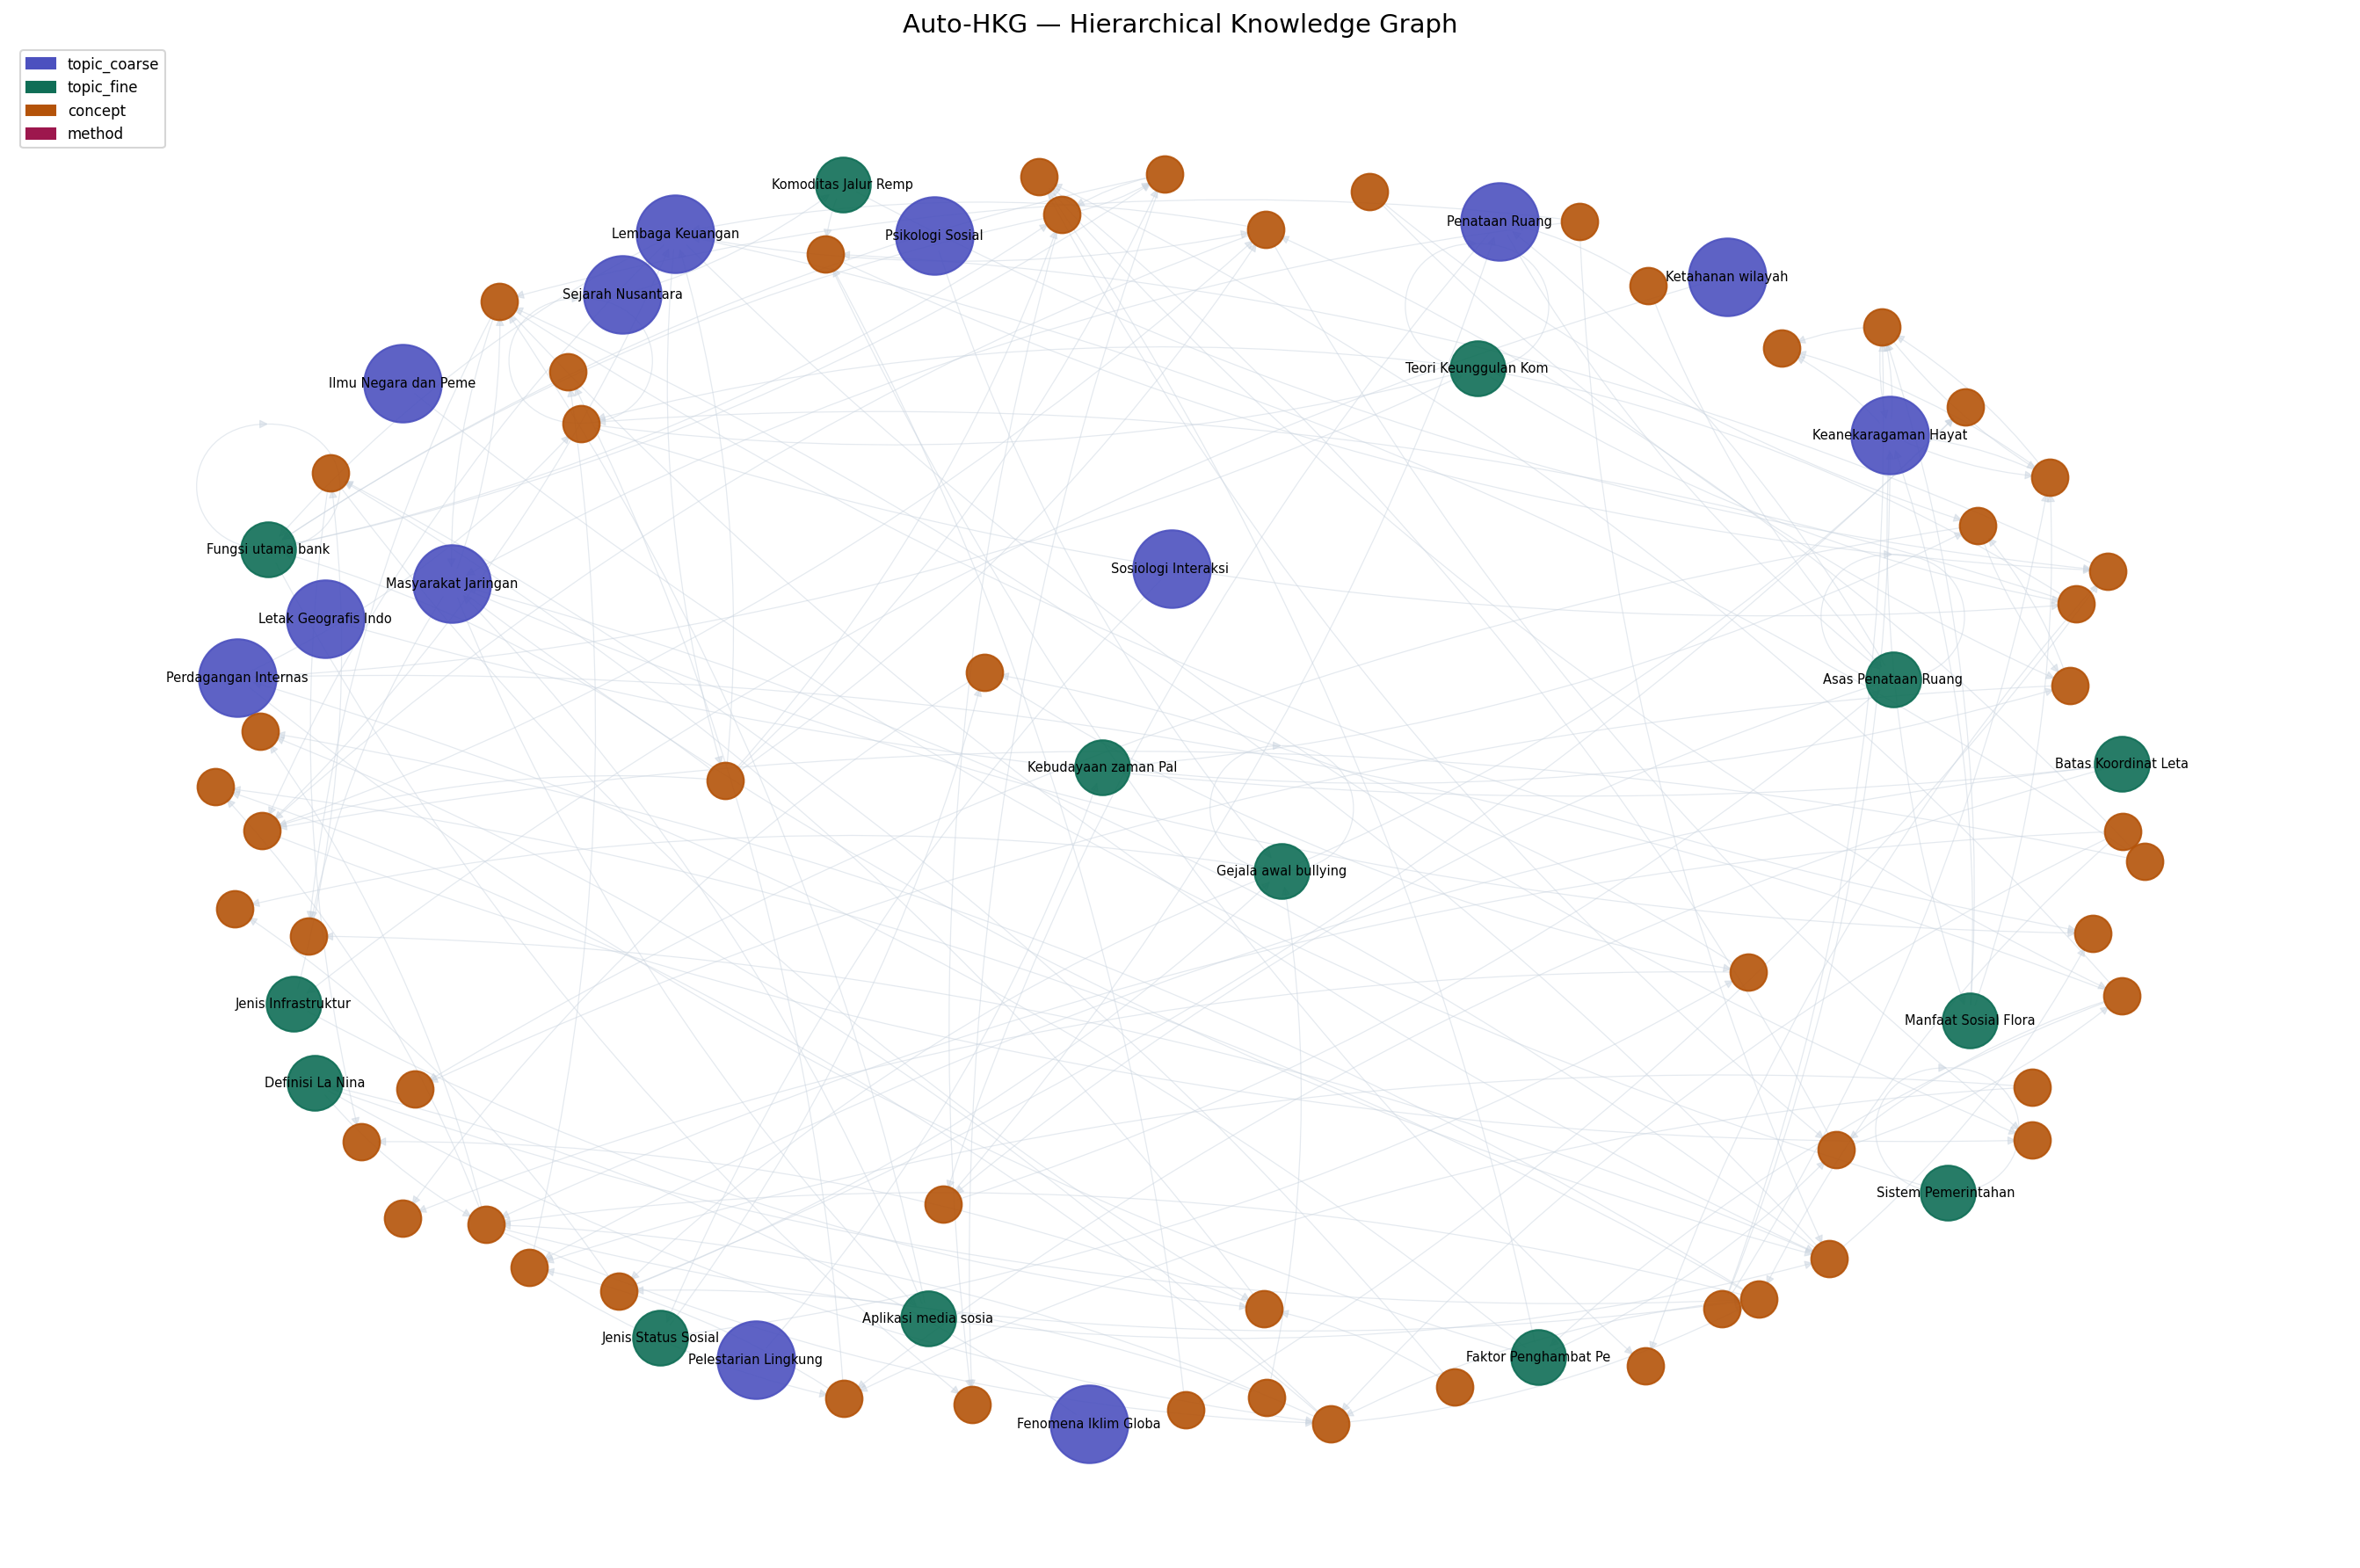

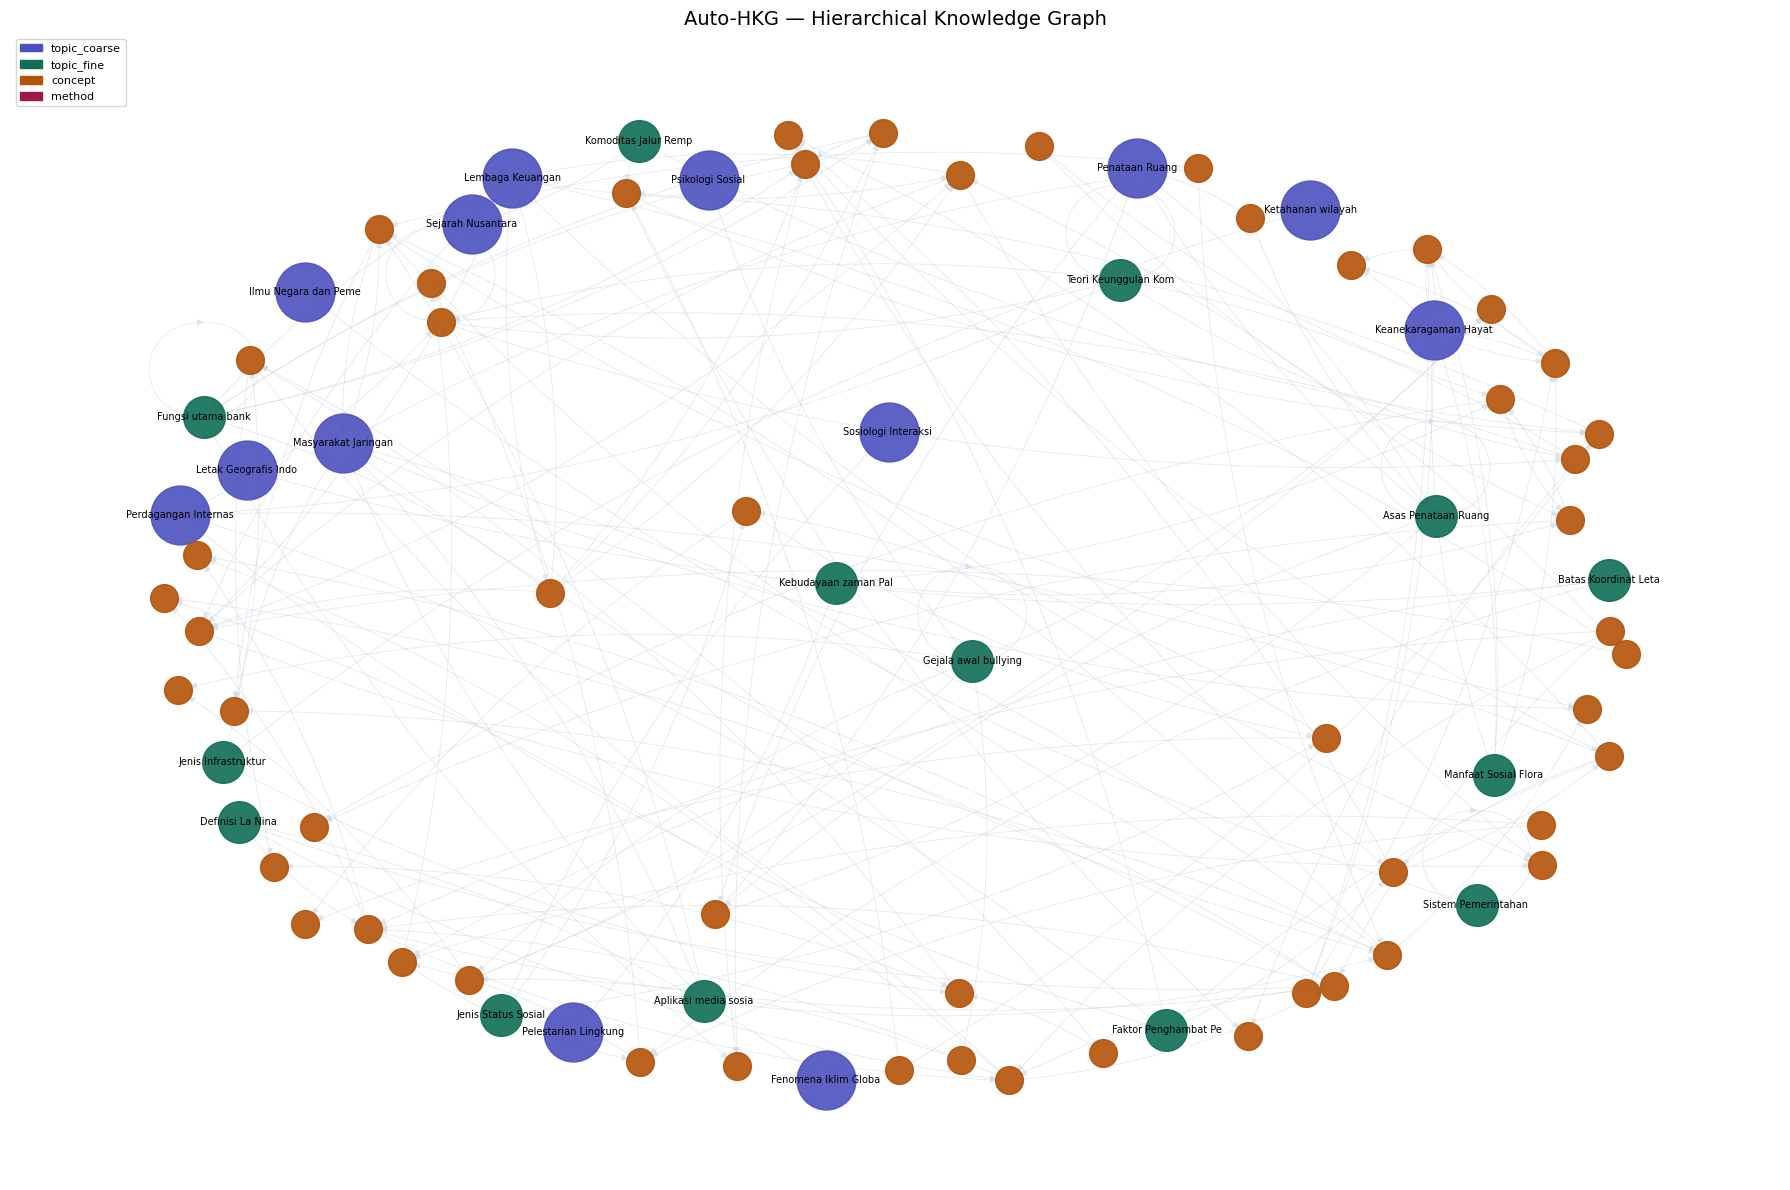

In [10]:
# ── Cell 9: Visualisasi graph statis (PNG) ────────────────────────────────────
from visualize_graph import plot_static
from IPython.display import Image

plot_static(G, max_nodes=80)
Image('output/graph/graph_static.png')


In [12]:
# ── Cell 11: Download semua output ────────────────────────────────────────────
import shutil
from google.colab import files

shutil.make_archive('auto_hkg_output', 'zip', 'output')
files.download('auto_hkg_output.zip')
print('✅ Download dimulai.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download dimulai.
